label
0    2095057
1     425694
Name: count, dtype: int64
Începem normalizarea datelor...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Date pregătite! Forma lui X: (2520751, 52). Forma lui y: (2520751,)
Mediul a fost creat cu succes! Forma unei stări: (52,)

Inițializăm Agentul DQN...
Using cpu device
Wrapping the env in a DummyVecEnv.
Începem antrenamentul efectiv. Te rog așteaptă...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 1e+03    |
|    ep_rew_mean      | 120      |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 4        |
|    fps              | 1001     |
|    time_elapsed     | 3        |
|    total_timesteps  | 4000     |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 0.000726 |
|    n_updates        | 974      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 1e+03    |
|    ep_rew_mean      | 510      |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 8        |
|    fps              | 1057     |
|    time_elapsed     | 7        |
|    total_timesteps  | 8000     |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 0.000751 |
|    n_updates      

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/matplotlib/backends/backend_pdf.py:1761: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(rgb8, mode='P')
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


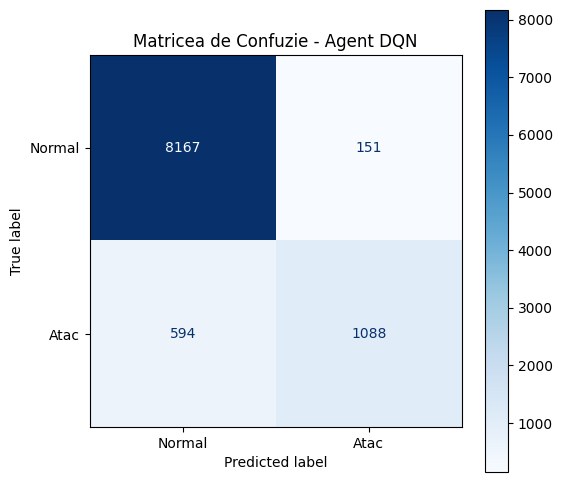


Graficul a fost salvat ca 'matrice_confuzie_dqn.pdf'.


In [18]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import time

df = pd.read_csv('sample_data/cicids2017_cleaned.csv')

df.columns = df.columns.str.strip()

df.replace([np.inf, -np.inf], np.nan, inplace=True);
df.dropna(inplace=True)

df['label'] = df['Attack Type'].apply(lambda x: 0 if x == 'Normal Traffic' else 1)

df.drop('Attack Type', axis=1, inplace=True)

print(df['label'].value_counts())

print("Începem normalizarea datelor...")

# Extragem etichetele (y) și caracteristicile (X)
y = df['label'].values
X_raw = df.drop('label', axis=1).values

# Normalizăm X (toate valorile vor fi între 0 și 1)
scaler = MinMaxScaler()
X = scaler.fit_transform(X_raw)

print(f"Date pregătite! Forma lui X: {X.shape}. Forma lui y: {y.shape}")

class IDSEnv(gym.Env):
    def __init__(self, X, y, max_steps=1000):
        super(IDSEnv, self).__init__()
        self.X = X
        self.y = y
        self.max_steps = max_steps
        self.current_step = 0
        self.n_samples = len(X)
        self.steps_taken = 0

        # Acțiuni posibile: 0 = Permite, 1 = Blochează
        self.action_space = spaces.Discrete(2)

        # Starea: Vectorul cu caracteristicile unui pachet de rețea
        self.observation_space = spaces.Box(
            low=0.0, high=1.0,
            shape=(X.shape[1],), dtype=np.float32
        )

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # Începem de la o poziție aleatorie din dataset pentru diversitate
        self.current_step = np.random.randint(0, self.n_samples - self.max_steps - 1)
        self.steps_taken = 0

        obs = self.X[self.current_step]
        return np.array(obs, dtype=np.float32), {}

    def step(self, action):
        actual_label = self.y[self.current_step]
        reward = 0

        # ----- AICI ESTE FUNCȚIA TA DE RECOMPENSĂ (Obiectivul O1) -----
        if action == actual_label:
            reward = 1.0  # Corect (True Positive sau True Negative)
        elif action == 1 and actual_label == 0:
            reward = -2.0 # ALARMĂ FALSĂ: Penalizare severă (a blocat un utilizator normal)
        elif action == 0 and actual_label == 1:
            reward = -1.0 # ATAC RATAT: Penalizare standard (a lăsat hackerul să treacă)
        # --------------------------------------------------------------

        # Trecem la pachetul următor
        self.current_step += 1
        self.steps_taken += 1

        # Oprim episodul dacă am atins limita de pași
        done = bool(self.steps_taken >= self.max_steps)
        truncated = False
        info = {'actual_label': actual_label, 'action_taken': action}

        next_obs = self.X[self.current_step]

        return np.array(next_obs, dtype=np.float32), reward, done, truncated, info

# Instanțiem mediul ca să verificăm că funcționează
env = IDSEnv(X, y)
obs, info = env.reset()
print(f"Mediul a fost creat cu succes! Forma unei stări: {obs.shape}")

print("\nInițializăm Agentul DQN...")

# 2. Împachetăm mediul într-un Monitor pentru a-i putea extrage performanța mai târziu
env = Monitor(IDSEnv(X, y))

# 3. Definim arhitectura modelului
# 'MlpPolicy' înseamnă Multi-Layer Perceptron (o rețea neuronală standard, perfectă pentru tabele cu date)
model = DQN(
    "MlpPolicy",
    env,
    learning_rate=0.001,      # Cât de repede învață din greșeli
    buffer_size=50000,        # Memoria lui pe termen scurt (câte experiențe reține)
    exploration_fraction=0.2, # Cât la sută din timp explorează acțiuni noi la întâmplare
    verbose=1                 # Ne afișează detalii în timp ce se antrenează
)

# 4. Pornim antrenamentul!
print("Începem antrenamentul efectiv. Te rog așteaptă...")
start_time = time.time()

model.learn(total_timesteps=20000)

end_time = time.time()
print(f"\nAntrenament finalizat cu succes în {round(end_time - start_time, 2)} secunde!")

# 5. Salvăm creierul antrenat (ca să nu o luăm de la zero data viitoare)
model.save("ids_dqn_agent")
print("Modelul a fost salvat ca 'ids_dqn_agent.zip'.")

print("Începem evaluarea agentului pe 10.000 de pachete aleatorii...")

# Alegem 10.000 de pachete (indecși) la întâmplare din setul de date
test_indices = np.random.choice(len(X), size=10000, replace=False)
X_test = X[test_indices]
y_test = y[test_indices]  # Acestea sunt etichetele reale (true_labels)

predictions = []

# Trecem fiecare pachet de test prin model pentru a vedea ce decizie ia
for obs in X_test:
    # Modelul ia decizia (deterministic=True)
    action, _states = model.predict(obs, deterministic=True)
    predictions.append(action)

# 1. Raportul Text (Precizie, Recall, F1-Score)
print("\n" + "="*40)
print("RAPORT DE CLASIFICARE (Metrici Licență)")
print("="*40)
print(classification_report(y_test, predictions, target_names=['Normal (0)', 'Atac (1)']))

# 2. Generarea Graficului (Matricea de Confuzie)
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Atac'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Matricea de Confuzie - Agent DQN')

# Salvăm vectorial ca să arate perfect în LaTeX!
plt.savefig('matrice_confuzie_dqn.pdf', format='pdf', bbox_inches='tight')
plt.show()

print("\nGraficul a fost salvat ca 'matrice_confuzie_dqn.pdf'.")

In [15]:
!pip install stable-baselines3[extra]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 4.7 MB/s eta 0:00:00
